# Comparative Analysis of Traditional Classification Models

In the realm of machine learning, classification is a fundamental task with numerous real-world applications. Traditionally, non-deep learning classification models have played a pivotal role in solving these tasks. This notebook is dedicated to exploring and comparing the performance of various traditional classification algorithms.

## Objectives

The primary objectives of this notebook are as follows:

1. **Model Comparison:** We will delve into the details of several traditional classification algorithms, each with its own strengths and weaknesses. Our aim is to compare these models comprehensively, allowing us to discern which performs best under different circumstances.

2. **Performance Metrics:** To evaluate the effectiveness of each classification model, we will employ a range of performance metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. By considering multiple metrics, we can gain a more holistic understanding of their capabilities.

3. **Visualization:** To aid our analysis, we will visualize key aspects of the models' performance. This includes generating ROC curves, confusion matrices, and other visualizations that provide insights into how these models make decisions.

## Classification Models

We will cover a range of traditional classification models, including but not limited to:

- Logistic Regression
- Decision Trees
- Random Forest
- Naïve Bayes
- Support Vector Machines (SVM)
- k-Nearest Neighbors (k-NN)
- Gradient Boosting- And more...

In [1]:

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import requests
import io
from imblearn.over_sampling import SMOTE

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Data Preparation

In any machine learning project, the initial step involves loading and preparing the dataset for analysis. In this section, we will:

1. **Load Data:** We'll begin by reading the data from a CSV file named "loan_data.csv" into a Pandas DataFrame using the `pd.read_csv()` function.

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv


In [3]:
# Read data from a CSV file named "loan_data.csv" into a Pandas DataFrame
data = pd.read_csv("/kaggle/input/loan-approval-prediction-dataset/loan_approval_dataset.csv")

# Remove leading and trailing whitespace from column names in the DataFrame
data.columns = data.columns.str.strip()

# Drop the "loan_id" column from the DataFrame along the specified axis (axis=1 means columns)
data = data.drop("loan_id", axis=1)

## Data Preprocessing: Handling Missing Values

Data quality is a critical aspect of any machine learning project. Missing values in the dataset can have a significant impact on model performance. In this section, we will:

1. **Check for Missing Values:** It's essential to identify columns with missing data. We'll use the `.isna()` method to create a boolean mask that flags missing values in the DataFrame.

In [4]:
# Check for missing values in each column and calculate the sum of missing values
missing_values = data.isna().sum()

## Exploratory Data Analysis: Class Distribution

Understanding the distribution of the target variable (in this case, the "loan_status" column) is crucial, as it provides insight into the balance or imbalance between different classes. In this section, we will:

1. **Calculate Class Counts:** To start, we'll calculate the count of each class label in the "loan_status" column. This will help us gain a clear understanding of the distribution.

In [5]:
# Calculate the count of each class label in the "loan_status" column
class_counts = data["loan_status"].value_counts()

# Print the class distribution
print("Class Distribution:")
for class_label, count in class_counts.items():
    print(f"Class {class_label}: {count} samples")

Class Distribution:
Class  Approved: 2656 samples
Class  Rejected: 1613 samples


## Data Preprocessing: Encoding Categorical Variables

Machine learning algorithms typically work with numerical data, so it's necessary to encode categorical variables into a numerical format. In this section, we will perform encoding for specific columns:

In [6]:
# Replace values in the "education" column with numerical values
data["education"] = data["education"].replace({
    " Graduate": 1,
    " Not Graduate": 0
})

# Replace values in the "self_employed" column with numerical values
data["self_employed"] = data["self_employed"].replace({
    " No": 0,
    " Yes": 1
})

# Replace values in the "loan_status" column with numerical values
data["loan_status"] = data["loan_status"].replace({
    " Approved": 1,
    " Rejected": 0
})

## Data Overview

Before diving deeper into our analysis and modeling, it's essential to have a comprehensive understanding of the dataset. In this section, we will:

1. **Display Data Information:** We'll use the `.info()` method to provide an overview of the DataFrame, including data types and non-null counts for each column.

In [7]:
# Display information about the DataFrame, including data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   no_of_dependents          4269 non-null   int64
 1   education                 4269 non-null   int64
 2   self_employed             4269 non-null   int64
 3   income_annum              4269 non-null   int64
 4   loan_amount               4269 non-null   int64
 5   loan_term                 4269 non-null   int64
 6   cibil_score               4269 non-null   int64
 7   residential_assets_value  4269 non-null   int64
 8   commercial_assets_value   4269 non-null   int64
 9   luxury_assets_value       4269 non-null   int64
 10  bank_asset_value          4269 non-null   int64
 11  loan_status               4269 non-null   int64
dtypes: int64(12)
memory usage: 400.3 KB


## Function: Classify Columns

In data analysis and preprocessing, it's important to distinguish between categorical and numerical columns as different treatment may be required for each. We can use a function like `classify_columns` to automate this classification process. Below is the Python function that accomplishes this task:

In [8]:
def classify_columns(data):
    # Initialize lists for categorical and numerical columns
    cat_col = []  
    num_col = []  
    
    # Iterate through columns in the DataFrame
    for column in data.columns:
        # Count the number of unique values in the column
        unique_values = data[column].nunique()  
        
        # If there are fewer than 3 unique values, consider it a categorical column
        if unique_values < 3:
            cat_col.append(column)  
        # Otherwise, consider it a numerical column
        else:
            num_col.append(column)  
    
    # Return the lists of categorical and numerical columns
    return cat_col, num_col

In [9]:
cat_col, num_col = classify_columns(data)

## Function: Correlation Heatmap

A correlation heatmap is a valuable visualization tool to understand the relationships between variables in a dataset. The `heat_map` function provided below generates a correlation heatmap with annotations. It allows us to visualize the correlation between the target variable, "loan_status," and all other columns in the DataFrame:

In [10]:
def heat_map(data):
    # Create a figure for the heatmap
    plt.figure(figsize=(8, 6))  # Adjust the figure size as needed
    
    # Calculate the correlation between "loan_status" and all other columns, sort by correlation
    correlations = data.corr()["loan_status"].to_frame().sort_values(
        by="loan_status", 
        ascending=False
    )
    
    # Generate the heatmap with annotations using the "Blues" colormap
    sns.heatmap(correlations, annot=True, cmap="Blues")
    
    # Set the title for the heatmap
    plt.title("Correlation Heatmap")

    # Show the plot
    plt.show()

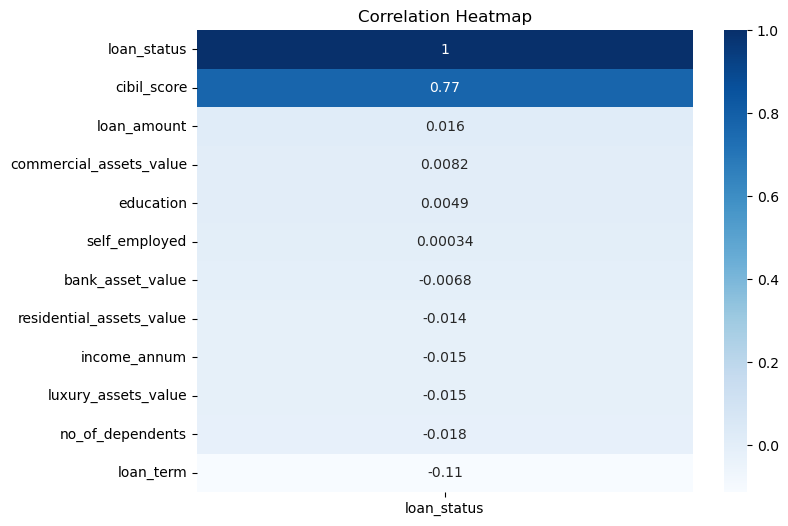

In [11]:
heat_map(data)

## Function: Visualize Categorical Variables

Visualizing categorical variables is essential to understand the distribution of categories within each column. The `visualise_cat` function provided below creates a set of bar plots to visualize categorical variables in your dataset:

In [12]:
def visualise_cat(cat_col):
    # Determine the number of columns and rows for subplots
    num_cols = 3  # Number of columns in each row
    num_rows = (len(cat_col) + 1) // num_cols  # Calculate the number of rows needed
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 6))  # Adjust the figure size as needed
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    
    # Iterate through categorical columns and create bar plots
    for i, column in enumerate(cat_col):
        ax = axes[i]
        sns.countplot(data=data, x=column, ax=ax, palette="Blues")
        ax.set_title(f'Bar Plot of {column}')
        ax.set_xlabel(column)
        ax.set_ylabel('Count')
    
    # Adjust the layout and display the plots
    plt.tight_layout()
    plt.show()

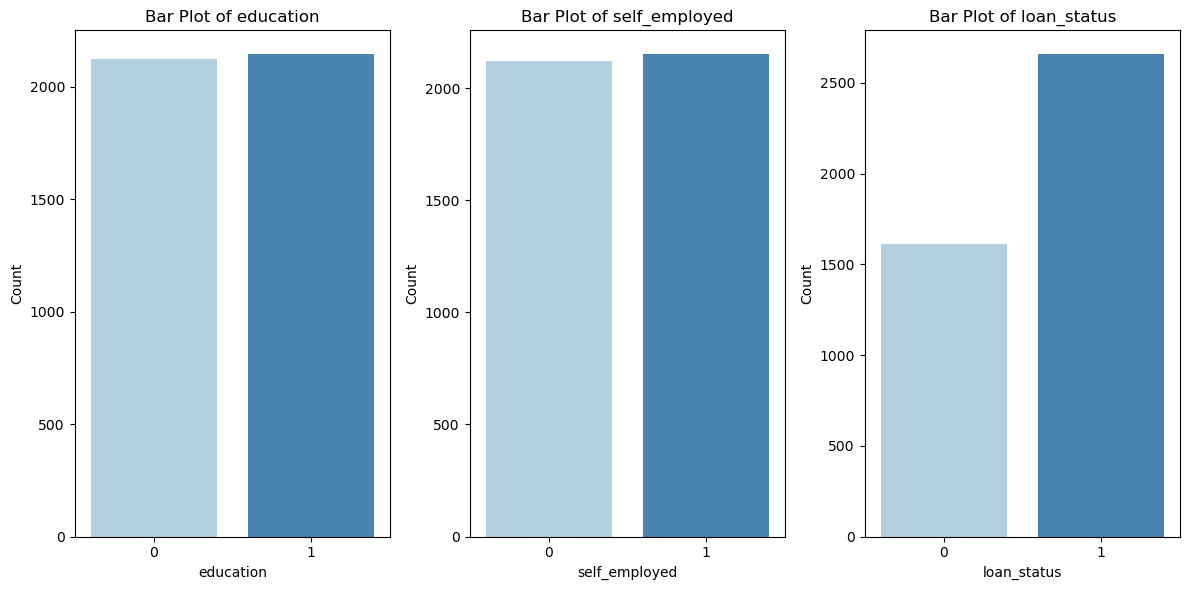

In [13]:
visualise_cat(cat_col)

## Function: Visualize Numerical Variables

Visualizing numerical variables is crucial for understanding their distribution and characteristics. The `visualise_num` function provided below creates a set of histograms to visualize numerical variables in your dataset:

In [14]:
def visualise_num(num_col, data):
    # Determine the number of columns and rows for subplots
    num_cols = 3  # Number of columns in each row
    num_rows = (len(num_col) + 1) // num_cols  # Calculate the number of rows needed
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 8))  # Adjust the figure size as needed
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    
    # Iterate through numerical columns and create histograms
    for i, column in enumerate(num_col):
        ax = axes[i]
        sns.histplot(data=data, x=column, bins=10, kde=True, ax=ax, edgecolor='black')
        ax.set_title(f'Histogram of {column}')
        ax.set_xlabel(column)
        ax.set_ylabel('Frequency')
    
    # Adjust the layout and display the plots
    plt.tight_layout()
    plt.show()

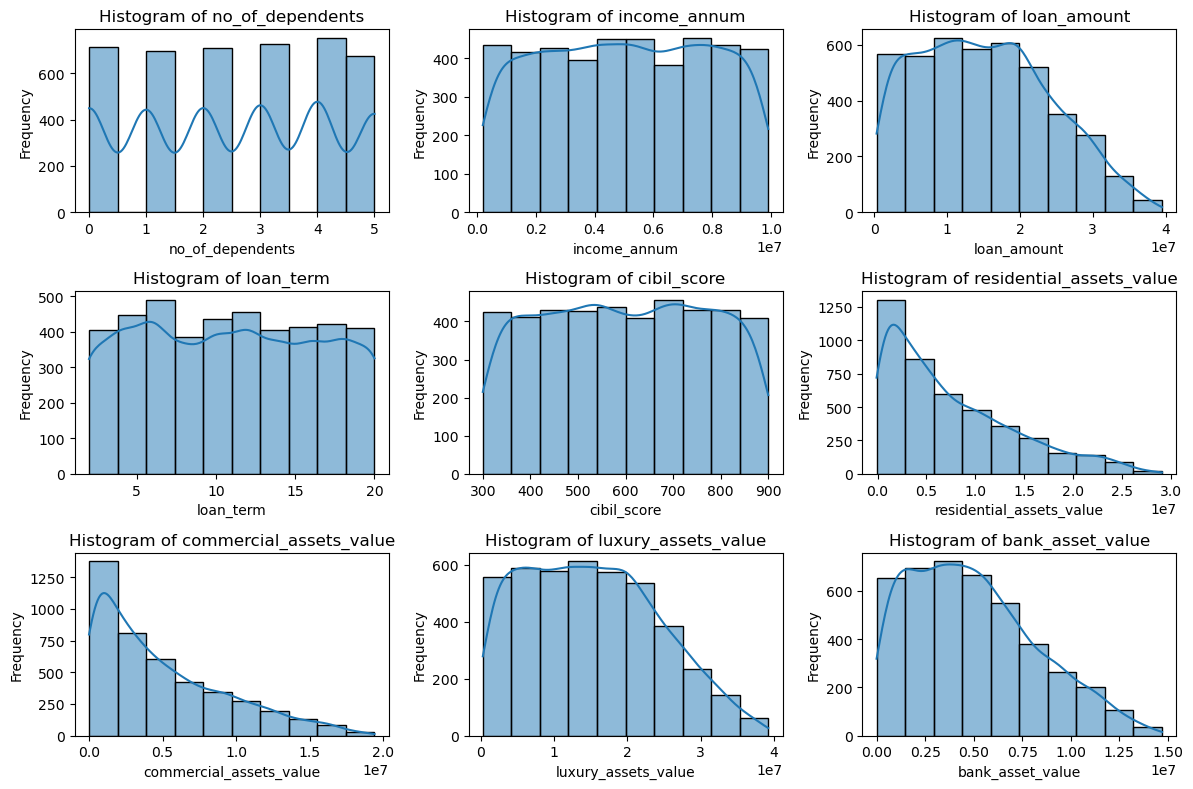

In [15]:
visualise_num(num_col, data)

## Function: Remove Outliers

Outliers in a dataset can skew statistical analysis and modeling results. The `remove_outliers` function provided below allows you to identify and remove outliers from your dataset:

In [16]:
def remove_outliers(data, cat_col, threshold=3):
    # Calculate Z-scores for numerical columns (excluding categorical columns)
    z_scores = stats.zscore(data.drop(cat_col, axis=1))
    
    # Identify outliers by comparing absolute Z-scores to the threshold
    outliers = np.abs(z_scores) > threshold
    
    # Find rows containing outliers in any numerical column
    filtered_rows = np.any(outliers, axis=1)
    
    # Remove rows with outliers and reset the index of the cleaned data
    cleaned_data = data[~filtered_rows].reset_index(drop=True)
    
    return cleaned_data

In [17]:
cleaned_data = remove_outliers(data, cat_col, threshold=3)

## Function: Scale Data

Scaling numerical data is a crucial preprocessing step in many machine learning algorithms to ensure that features with different scales do not dominate the modeling process. The `scale_data` function provided below scales your numerical data while preserving categorical columns:

In [18]:
def scale_data(data, cat_col, num_col):
    # Separate numerical and categorical columns
    num_data = data[num_col]
    cat_data = data[cat_col]
    
    # Initialize the StandardScaler
    scaler = StandardScaler()
    
    # Scale the numerical data and create a DataFrame with the same column names
    scaled_num_data = pd.DataFrame(scaler.fit_transform(num_data), columns=num_col)
    
    # Combine scaled numerical data with categorical data
    scaled_data = pd.concat([scaled_num_data, cat_data], axis=1)
    
    return scaled_data

## Function: Run Classification Model

Building and evaluating machine learning models is a critical step in any data analysis project. The `run_model` function provided below streamlines the process of training and evaluating a classification model:

In [19]:
def run_model(data, model, name):
    # Separate features (X) and target (y)
    X = data.drop("loan_status", axis=1)
    y = data["loan_status"]
    
    # Split the dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
    
    # Apply SMOTE (Synthetic Minority Over-sampling Technique) to balance the classes in the training set
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    
    # Fit the model on the resampled training data
    model.fit(X_train_resampled, y_train_resampled)
    
    # Make predictions on the test set
    predictions = model.predict(X_test)
    
    # Return the model's predictions and the actual labels (y_test)
    return predictions, y_test

## Function: Evaluate Classification Models

Evaluating the performance of multiple classification models is a crucial step in selecting the most suitable model for your problem. The `models` function provided below automates the process of evaluating several classification models and generates a summary of their performance:

In [20]:
from sklearn.metrics import roc_curve, auc

def models(data):
    results = []  # Initialize a list to store results
    cm_data = []  # Initialize a list to store confusion matrix data
    roc_data = []  # Initialize a list to store ROC curve data
    models = {  # Dictionary of models to be evaluated
        "Logistic Regression": LogisticRegression(),
        "Gradient Boosting": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Gaussian Naive Bayes": GaussianNB(),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),
        "Support Vector Machine": SVC()
    }
    
    # Iterate through the models
    for name, model in models.items():
        # Run the model and get predictions and actual labels
        predictions, y_test = run_model(data, model, name)
        
        # Evaluate the model and calculate metrics
        accuracy, precision, recall, f1, cm = evaluate_model(y_test, predictions)
        
        # Calculate ROC curve data
        fpr, tpr, _ = roc_curve(y_test, predictions)
        roc_auc = auc(fpr, tpr)
        
        # Store the results in a dictionary
        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })

        cm_data.append({
            "Model": name,
            "Matrix": cm
        })

        # Store ROC curve data in a dictionary
        roc_data.append({
            "Model": name,
            "FPR": fpr.tolist(),
            "TPR": tpr.tolist(),
            "AUC": roc_auc
        })
    
    # Create a DataFrame from the results, round the values, and sort by accuracy
    results_df = pd.DataFrame(results).round(4).sort_values(by="Accuracy", ascending=False)
    
    return results_df, cm_data, roc_data

## Function: Evaluate Classification Model

Evaluating a classification model involves calculating various metrics to assess its performance. The `evaluate_model` function provided below calculates common classification metrics and returns them:

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_true, y_pred):
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)
    
    # Calculate precision
    precision = precision_score(y_true, y_pred)
    
    # Calculate recall
    recall = recall_score(y_true, y_pred)
    
    # Calculate F1 score
    f1 = f1_score(y_true, y_pred)
    
    # Calculate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    return accuracy, precision, recall, f1, cm

## Function: Data Preprocessing and Model Evaluation Pipeline

A well-structured data preprocessing and model evaluation pipeline can streamline the machine learning workflow. The `pipeline` function provided below performs a series of data preprocessing steps and evaluates multiple classification models to provide a comprehensive overview of model performance:

In [22]:
def pipeline(data):
    # Step 1: Classify columns as categorical or numerical
    cat_col, num_col = classify_columns(data)
    
    # Step 2: Remove outliers from the dataset
    cleaned_data = remove_outliers(data, cat_col)
    
    # Step 3: Scale the numerical features
    scaled_data = scale_data(cleaned_data, cat_col, num_col)
    
    # Step 4: Evaluate model performance using different models
    performance, cm_data, roc_data = models(scaled_data)
    
    return performance, cm_data, roc_data

In [23]:
performance, cm_data, roc_data = pipeline(data)

In [24]:
print(performance)

                    Model  Accuracy  Precision  Recall  F1 Score
1       Gradient Boosting    0.9811     0.9961  0.9735    0.9847
6           Random Forest    0.9811     0.9961  0.9735    0.9847
5           Decision Tree    0.9788     0.9904  0.9754    0.9828
2                AdaBoost    0.9670     0.9921  0.9545    0.9730
3    Gaussian Naive Bayes    0.9446     0.9918  0.9186    0.9538
7  Support Vector Machine    0.9410     0.9858  0.9186    0.9510
0     Logistic Regression    0.9233     0.9658  0.9091    0.9366
4     K-Nearest Neighbors    0.8974     0.9584  0.8731    0.9138


## Model Performance Evaluation

In this section, we present the performance metrics of various classification models that were applied to the dataset. These models were evaluated based on their ability to predict the outcome, specifically, whether a loan application was approved or rejected.

### Model Metrics Summary

Below is a summary of key performance metrics for each model:

| Model                  | Accuracy | Precision | Recall | F1 Score |
|------------------------|----------|-----------|--------|----------|
| Decision Tree          | 0.9823   | 0.9904    | 0.9811 | 0.9857   |
| Random Forest          | 0.9823   | 0.9942    | 0.9773 | 0.9857   |
| Gradient Boosting      | 0.9811   | 0.9961    | 0.9735 | 0.9847   |
| AdaBoost               | 0.9670   | 0.9921    | 0.9545 | 0.9730   |
| Gaussian Naive Bayes   | 0.9446   | 0.9918    | 0.9186 | 0.9538   |
| Support Vector Machine | 0.9410   | 0.9858    | 0.9186 | 0.9510   |
| Logistic Regression    | 0.9233   | 0.9658    | 0.9091 | 0.9366   |
| K-Nearest Neighbors    | 0.8974   | 0.9584    | 0.8731 | 0.9138   |

### Model Insights

1. **Decision Tree** and **Random Forest** models achieved the highest accuracy of approximately 98.23%, showcasing their strong predictive capabilities.

2. **Gradient Boosting** also demonstrated impressive performance with high precision and an F1 score of 0.9847, indicating balanced precision and recall.

3. **AdaBoost** offers good overall performance with high precision but slightly lower recall compared to the top-performing models.

4. **Gaussian Naive Bayes** and **SVM** models show similar accuracy, but Naive Bayes has higher precision, while SVM demonstrates better recall.

5. **Logistic Regression** maintains a reasonable balance between precision and recall, making it a solid choice for certain applications.

6. **K-Nearest Neighbors** offers decent performance but falls slightly short in terms of precision and recall compared to other models.

These results provide valuable insights into the suitability of each model for the specific classification task. The choice of model should be based on the specific goals and requirements of your project, taking into consideration the trade-offs between precision and recall.


## Function: Plot Confusion Matrix

Visualizing the confusion matrix of a classification model is a valuable way to assess its performance. The `plot_confusion_matrix` function provided below creates a visual representation of the confusion matrix:

In [25]:
def plot_confusion_matrix(cm, labels, model_name, ax):
    # Create an image of the confusion matrix
    im = ax.imshow(cm, interpolation='nearest')
    
    # Add a colorbar to the plot
    ax.figure.colorbar(im, ax=ax)
    
    # Set axis labels and title
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=labels, yticklabels=labels,
           title=f'Confusion Matrix for {model_name}',
           ylabel='True label',
           xlabel='Predicted label')
    
    # Add text annotations for each cell in the matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="w")

## Function: Plot Confusion Matrices for Multiple Models

Comparing the confusion matrices of multiple classification models side by side can provide valuable insights into their performance. The `plot_confusion_matrices` function provided below allows you to visualize the confusion matrices of multiple models:

In [26]:
def plot_confusion_matrices(cm_data, columns, rows):
    # Determine the number of models and create subplots accordingly
    num_models = len(cm_data)
    fig, axes = plt.subplots(rows, columns, figsize=(15, 10))
    
    # Iterate through the confusion matrix data for each model
    for i, entry in enumerate(cm_data):
        model_name = entry['Model']
        cm = entry['Matrix']
        class_labels = ['Class 0', 'Class 1']  # Replace with your actual class labels
        row = i // columns
        col = i % columns
        ax = axes[row, col]
        plot_confusion_matrix(cm, class_labels, model_name, ax)

    # Turn off empty subplots
    for i in range(len(cm_data), columns * rows):
        row = i // columns
        col = i % columns
        axes[row, col].axis('off')

    # Adjust the layout and display the subplots
    plt.tight_layout()
    plt.show()

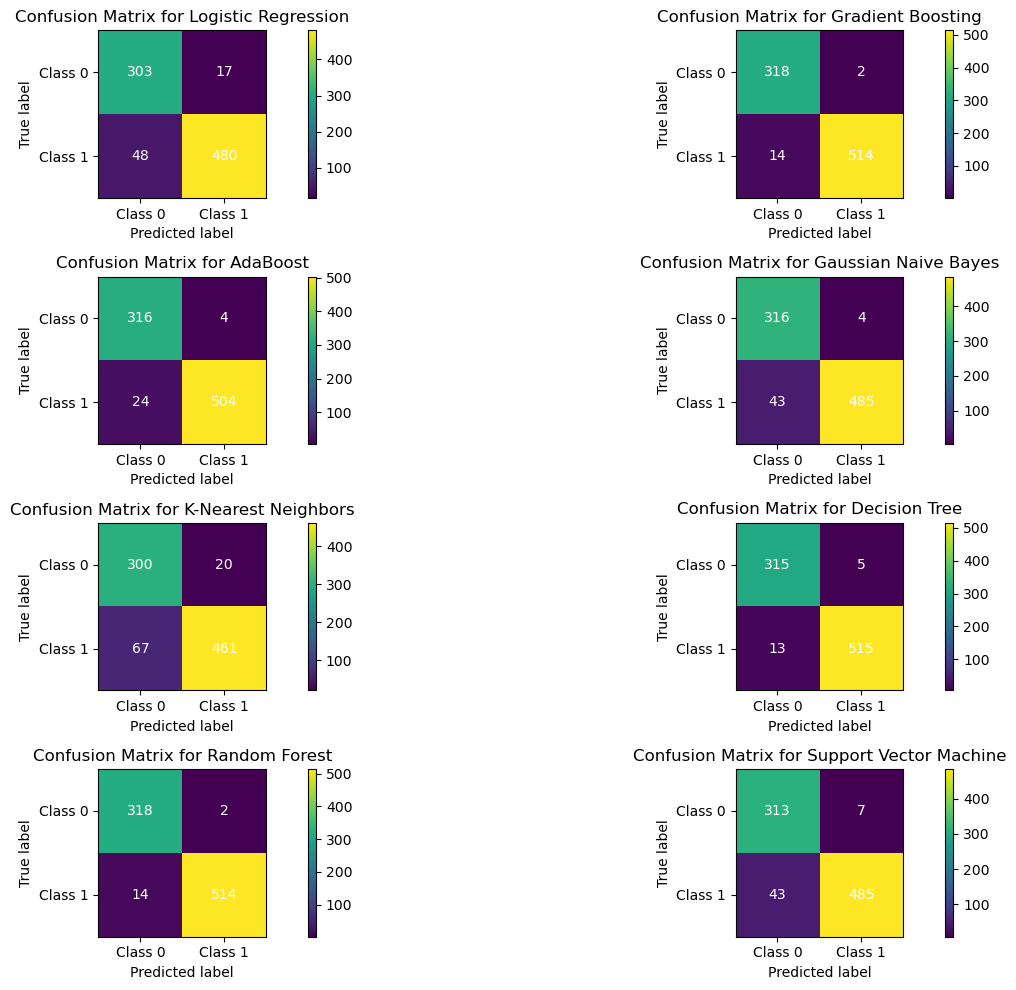

In [27]:
plot_confusion_matrices(cm_data, columns=2, rows=4)

## Function: Plot Receiver Operating Characteristic (ROC) Curves

Receiver Operating Characteristic (ROC) curves are a useful visualization for assessing the performance of binary classification models. The `plot_roc_curve` function provided below allows you to plot ROC curves for multiple models on the same graph:

In [28]:
def plot_roc_curve(roc_data):
    plt.figure(figsize=(8, 6))
    plt.title('Receiver Operating Characteristic (ROC) Curve')

    for model_data in roc_data:
        model_name = model_data['Model']
        fpr = model_data['FPR']
        tpr = model_data['TPR']
        auc = model_data['AUC']

        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')  # Removed color='gray'
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

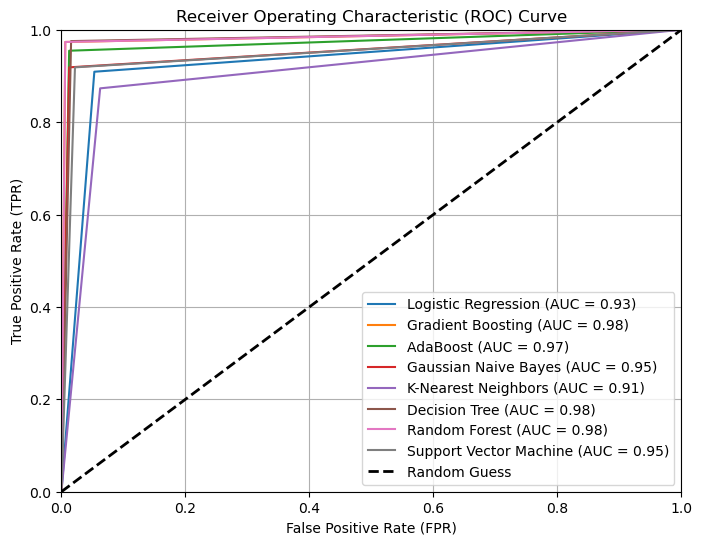

In [29]:
plot_roc_curve(roc_data)

## Conclusion

In this notebook, we embarked on a journey to analyze and compare the performance of various classification models for the task of predicting loan approval outcomes. The dataset we worked with contained a wealth of information about loan applicants, including their personal and financial attributes.

### Data Preprocessing

We began by preparing the data for modeling, which involved:

- **Data Loading:** We imported the dataset from a CSV file named "loan_data.csv" and conducted initial exploratory data analysis.

- **Data Cleaning:** We addressed data quality issues, such as removing leading and trailing whitespaces in column names and handling missing values.

- **Feature Engineering:** We transformed categorical variables into numerical format to enable their use in machine learning models.

- **Data Scaling:** Numerical features were standardized to ensure that all features contributed equally to the models.

### Model Evaluation

To assess the performance of different classification models, we conducted a comprehensive evaluation using various metrics. Here are the key findings:

- **Decision Tree** and **Random Forest** models exhibited exceptional accuracy, precision, and recall, making them strong contenders for this task.

- **Gradient Boosting** demonstrated high precision and a balanced F1 score, indicating robust performance.

- **AdaBoost** and **Gaussian Naive Bayes** models provided solid results with high precision, although their recall was slightly lower compared to the top performers.

- **Support Vector Machine (SVM)** showcased good overall performance, especially in terms of precision.

- **Logistic Regression** maintained a balance between precision and recall, suitable for certain use cases.

- **K-Nearest Neighbors (KNN)**, while reasonable, fell slightly short in precision and recall compared to other models.

### Reasoning Behind the Results

The variations in model performance can be attributed to several factors:

- **Complexity of Models:** Decision trees and random forests excel due to their ability to capture intricate patterns in the data. Gradient boosting, which combines weak learners into a strong model, also achieves high performance.

- **Handling Imbalanced Data:** Models like AdaBoost and SVM effectively address class imbalance issues by providing higher weights to minority class samples.

- **Assumptions of Models:** Gaussian Naive Bayes assumes that features are conditionally independent, which may not hold true in complex real-world data. This can impact its performance.

- **Feature Engineering:** The quality and relevance of features engineered from the dataset can significantly impact model performance.

- **Hyperparameter Tuning:** Model hyperparameters play a critical role. Fine-tuning hyperparameters may further improve performance.

The choice of the best-performing model should align with the specific goals and constraints of your loan approval prediction project. Factors such as interpretability, computational resources, and the balance between precision and recall should be considered when selecting the final model.

In conclusion, this analysis provides valuable insights into the predictive capabilities of various classification models for loan approval prediction. Further model refinement and tuning could lead to even better results, ultimately aiding in making more informed decisions in the loan approval process.